# End-to-End ML Workflow (Deployable, Explainable, Reproducible)

**Objective.** A production-minded ML workflow that you can **re-run, audit, and ship**.  
Design pillars: **no data leakage**, **pipelines for reproducibility**, **diagnostics for interpretability**, and **versioned artifacts** (models, figures, reports).

**What this notebook produces**
- **Models** saved under `models/` (full pipelines: preprocessing + estimator).
- **Figures** under `figures/` (all plots referenced below).
- **Reports** under `reports/` (CSV metrics + JSON summary index).

---

## Roadmap

### 1) Principles & Setup
- Project structure, seeding, and why all preprocessing lives **inside** pipelines.
- Reproducibility knobs (random seeds, deterministic splits).

### 2) Dataset A — Breast Cancer (Binary Classification)
- **Exploration → Stratified Split → PCA (train-only)**  
  Visual sanity checks without leaking information.
- **Modeling (LogReg / SVM / Random Forest) with CV**  
  Compact hyperparameter grids; best pipeline persisted.
- **Threshold tuning & probability calibration**  
  Default 0.5 vs tuned threshold (F1-driven) + calibration curve and Brier score.
- **Diagnostics**  
  ROC curve, Precision–Recall curve, Confusion Matrices (default vs tuned), Learning Curve.  
  Optional feature/coef views when PCA is not active.
- **Capacity sweep**  
  Train vs test performance as model capacity varies (underfit ↔ right-fit ↔ overfit).

### 3) Dataset B — Regression with Missingness
- **Missingness simulation**: MCAR and MAR patterns; rationale and risks.
- **Pipelines with imputation** (median) and scaling; **Ridge** vs **Random Forest**.
- **Residual diagnostics**  
  Residuals vs predicted, histogram of residuals, standardized residuals for outlier spotting.
- **Capacity sweep (regression)**  
  U-shaped test error curve to identify right-fit region.

### 4) PyTorch Neural Network (on Dataset A)
- Compact MLP classifier with **BCEWithLogitsLoss**.
- **Train/Validation curves**, early-stopping by best validation loss.
- Saved bundle (weights + scaler) for inference parity.

### 5) Model Cards & Reproducibility Appendix
- What was trained, how, with which preprocessing, metrics, and known limitations.
- `reports/summary.json` indexing all artifacts for downstream tooling.

---

## How to read the results
- **Prefer pipelines**: any model file you load from `models/` can predict on raw data—no separate scaler needed.
- **Check calibration** before using probabilities in downstream decisions.
- **Use capacity sweeps** to choose complexity; avoid relying on a single split/score.
- **Inspect residuals** (regression) and confusion matrices (classification) to understand failure modes.

---

## Abbreviation glossary (for clarity)

- **LogReg** — Logistic Regression (linear classifier with L2 penalty by default).  
- **SVM** — Support Vector Machine (here: RBF kernel with probability estimates enabled).  
- **RF** — Random Forest (ensemble of decision trees).  
- **Ridge** — Linear regression with L2 regularization.  
- **PCA** — Principal Component Analysis (unsupervised dimensionality reduction).  
- **EDA** — Exploratory Data Analysis (summary stats, distributions, quick visuals).  
- **CV** — Cross-Validation (here: k-fold Stratified for classification).  
- **ROC** — Receiver Operating Characteristic curve (TPR vs FPR across thresholds); **AUC** is its area.  
- **PR** — Precision–Recall curve (useful under class imbalance); **AP** is its area (average precision).  
- **CM** — Confusion Matrix (TP/FP/FN/TN counts at a chosen threshold).  
- **Brier score** — Mean squared error of probabilistic predictions (lower is better).  
- **MCAR** — Missing Completely At Random (missingness independent of data).  
- **MAR** — Missing At Random (missingness depends on observed variables).  
- **NN / MLP** — Neural Network / Multi-Layer Perceptron (feed-forward network).  
- **BCEWithLogitsLoss** — Binary cross-entropy applied to raw logits (numerically stable).  
- **Right-fit** — Model capacity that minimizes generalization error without overfitting.


## 0) Principles & Setup (read this first)

**Why this matters.** Reliable results come from disciplined process, not lucky splits. We lock down reproducibility, isolate preprocessing to avoid leakage, and save every artifact needed to rerun or audit.

### Core principles
- **Pipelines prevent leakage.**  
  All preprocessing (imputation, scaling, PCA, etc.) is *inside* the model pipeline. We `fit` pipelines on training folds only; test/val data sees `transform` only. No transforms are ever fit on the full dataset.

- **Splitting policy.**  
  - **Classification:** use **stratified** splits/CV so class proportions are preserved in every fold.  
  - **Regression:** standard random splits/CV (stratification isn’t applicable).

- **Reproducibility.**  
  Fixed random seeds for NumPy/torch/sklearn, deterministic splits, and persisted model pipelines. If runtime differs across machines, seeds at least ensure comparable outcomes.

- **Artifacted workflow.**  
  Everything is written to disk for traceability:
```

models/   # serialized pipelines (preprocessing + estimator)
figures/  # all plots (PCA, ROC, PR, CM, calibration, residuals, sweeps, NN curves)
reports/  # CSV metrics and JSON summary index

```

- **Evaluation protocol.**  
- **Classification metrics:** **Accuracy**, **ROC–AUC**, **PR–AP**, plus confusion matrices at default and tuned thresholds.  
- **Regression metrics:** **MSE** and **R²** on held-out data.  
Use CV means for model selection; report held-out test metrics once.

- **Diagnostics are mandatory, not optional.**  
Curves and residual checks expose failure modes a single score cannot:
- Classification: ROC, PR, calibration curve + Brier score, learning curve, capacity sweep.  
- Regression: residuals vs predicted, residual histogram, standardized residuals, capacity sweep.

- **Thresholds & probabilities.**  
Default 0.5 is rarely optimal. We tune a threshold (e.g., maximize F1 or enforce minimum recall) and inspect calibration before using probabilities downstream.

### Abbreviations used here
- **Pipeline** — A single object that includes preprocessing and the model; ensures no-leak training and reproducible inference.  
- **Stratified split** — Train/test (or CV folds) preserve the original class proportions.  
- **ROC–AUC** — Area under the Receiver Operating Characteristic (TPR vs FPR across thresholds).  
- **PR–AP** — Area under the Precision–Recall curve (preferred under class imbalance).  
- **MSE** — Mean Squared Error (lower is better).  
- **R²** — Coefficient of determination; variance explained (higher is better).  
- **Brier score** — Mean squared error of predicted probabilities (calibration; lower is better).


In [7]:

import os, json, numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt
from pathlib import Path

# sklearn
from sklearn.datasets import load_breast_cancer, make_regression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, classification_report,
                             mean_squared_error, r2_score, brier_score_loss)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve

# torch
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

# Paths and seeds
BASE = Path("."); MODELS = BASE/"models"; FIGS = BASE/"figures"; REPTS = BASE/"reports"
for p in (MODELS, FIGS, REPTS): p.mkdir(parents=True, exist_ok=True)
RNG = 42; np.random.seed(RNG); torch.manual_seed(RNG)



## 1. Dataset A — Breast Cancer (Classification)
**Objective:** Predict *benign vs malignant*. We treat this as a high-stakes classification: false negatives are costly.  
We start with **EDA** and a **leak-free** split, then **PCA** purely for visualization (fitted on *train only*).


In [ ]:
d1 = {'col1': [10, 20, 30], 'col2': ['x', 'y', 'z']}
d2 = [[10, 20, 30], ['x', 'y', 'z']]
ser = pd.Series(d1, name='ser')
display(ser)
print(ser.shape)

,count,mean,std,min,25%,50%,75%,max,missing
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,0
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,0
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,0
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,0
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,0


Class balance: {1: 0.6274165202108963, 0: 0.37258347978910367}


FileNotFoundError: [Errno 2] No such file or directory: 'figures/A_pca_train.png'

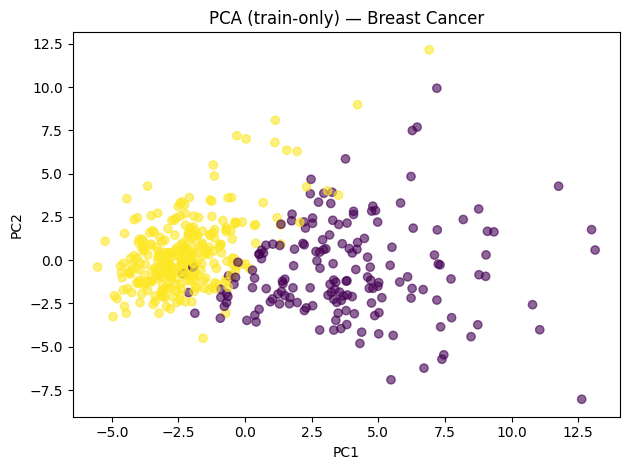

In [45]:

data = load_breast_cancer()
XA = pd.DataFrame(data.data, columns=data.feature_names)
yA = pd.Series(data.target, name="target") # target = TP or TN (?)
display(XA.describe().T.assign(missing=XA.isnull().sum()))
print("Class balance:", yA.value_counts(normalize=True).to_dict())

# Stratified split
# Stratified: ensures class frequencies are relatively similar across train and test set.
XA_tr, XA_te, yA_tr, yA_te = train_test_split(XA, yA, test_size=0.2, stratify=yA, random_state=RNG)

# PCA (train-only) for visualization
scA = StandardScaler().fit(XA_tr)
ZA_tr = scA.transform(XA_tr)
pcaA = PCA(n_components=2, random_state=RNG).fit(ZA_tr)
Z = pcaA.transform(ZA_tr)

plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=yA_tr, alpha=0.6)
plt.title("PCA (train-only) — Breast Cancer")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.savefig(FIGS/"A_pca_train.png", bbox_inches="tight"); 
# plt.close()
print("Saved:", FIGS/"A_pca_train.png")


### Missingness demo — show the **true removed value** and each **imputed value**
We inject MCAR (~12%) into 4 features, then compare:
- **Leaky**: global-mean fill (invalid, uses test info)
- **No-leak**: train-mean fill (pandas)
- **Pipeline**: `SimpleImputer(median)` fit on train only

We display a few **missing cells from the test split** with:
- the **true value** (from original `XA`),
- each **imputed value**, and
- the **absolute error** vs the truth.

Finally, we compute **MAE across all test missing cells** per strategy to quantify differences even when accuracy ties.


In [3]:
# --- Inject MCAR missingness into a copy of XA (≈12% in 4 informative columns) ---
XA_miss = XA.copy()
rng = np.random.default_rng(RNG)

cols_to_corrupt = ["mean radius", "mean texture", "mean perimeter", "mean area"]
mask = rng.uniform(size=(XA_miss.shape[0], len(cols_to_corrupt))) < 0.12  # ~12% MCAR
XA_miss.loc[:, cols_to_corrupt] = XA_miss.loc[:, cols_to_corrupt].mask(mask)

print("Missing counts (top 8):")
display(XA_miss.isnull().sum().sort_values(ascending=False).head(8))

# Common imports
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def make_clf_no_imputer():
    return Pipeline([("sc", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=600, random_state=RNG))])

def make_clf_with_imputer(strategy="median"):
    return Pipeline([("imp", SimpleImputer(strategy=strategy)),
                     ("sc", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=600, random_state=RNG))])

# =========================
# 1) Leaky (global mean) – invalid
# =========================
XA_leaky = XA_miss.fillna(XA_miss.mean(numeric_only=True))
X_leak_tr, X_leak_te, y_leak_tr, y_leak_te = train_test_split(
    XA_leaky, yA, test_size=0.2, stratify=yA, random_state=RNG
)
leaky_pipe = make_clf_no_imputer().fit(X_leak_tr, y_leak_tr)
leaky_acc = leaky_pipe.score(X_leak_te, y_leak_te)
print(f"[Leaky] fillna(global mean) → Test acc: {leaky_acc:.3f}  ← INVALID")

# =========================
# 2) No-leak (train mean)
# =========================
XA_tr_m, XA_te_m, yA_tr_m, yA_te_m = train_test_split(
    XA_miss, yA, test_size=0.2, stratify=yA, random_state=RNG
)
train_means = XA_tr_m.mean(numeric_only=True)
XA_tr_filled = XA_tr_m.fillna(train_means)
XA_te_filled = XA_te_m.fillna(train_means)

no_leak_pipe = make_clf_no_imputer().fit(XA_tr_filled, yA_tr_m)
no_leak_acc = no_leak_pipe.score(XA_te_filled, yA_te_m)
print(f"[No-leak] pandas fillna(train means) → Test acc: {no_leak_acc:.3f}")

# =========================
# 3) Pipeline (SimpleImputer median) – preferred
# =========================
XA_tr_raw, XA_te_raw, yA_tr_raw, yA_te_raw = train_test_split(
    XA_miss, yA, test_size=0.2, stratify=yA, random_state=RNG
)
impute_pipeline = make_clf_with_imputer(strategy="median").fit(XA_tr_raw, yA_tr_raw)
pipe_acc = impute_pipeline.score(XA_te_raw, yA_te_raw)
print(f"[Pipeline+Imputer(median)] → Test acc: {pipe_acc:.3f}  ← Preferred")

# =========================================================
# Show actual removed values vs each imputed value (TEST split)
# =========================================================
import pandas as pd
import numpy as np

# Identify missing cells in the test split used in (2)
missing_cells = []
for col in cols_to_corrupt:
    idx = XA_te_m.index[XA_te_m[col].isna()]
    missing_cells += [(i, col) for i in idx]

# Build imputation stats for each strategy
global_means = XA_miss.mean(numeric_only=True)
train_means = train_means  # from above
imp_stats = pd.Series(impute_pipeline.named_steps["imp"].statistics_, index=XA_tr_raw.columns)

# Create a small demo table with a few examples
examples = missing_cells[: min(10, len(missing_cells))]
rows = []
for i, col in examples:
    true_val = XA.loc[i, col]  # original truth
    leaky_val = global_means[col]
    noleak_val = train_means[col]
    pipe_val = imp_stats[col]
    rows.append({
        "row_id": int(i),
        "feature": col,
        "true_value": float(true_val),
        "leaky_imputed": float(leaky_val),
        "no_leak_imputed": float(noleak_val),
        "pipeline_imputed": float(pipe_val),
        "abs_err_leaky": float(abs(true_val - leaky_val)),
        "abs_err_no_leak": float(abs(true_val - noleak_val)),
        "abs_err_pipeline": float(abs(true_val - pipe_val)),
    })
impute_demo = pd.DataFrame(rows)
display(impute_demo)

# =========================================================
# Aggregate MAE across ALL test-missing cells (more robust than eyeballing)
# =========================================================
def mae_over_missing(X_test_with_nan, truth_X, imputer_stats: pd.Series):
    pairs = [(i, c) for c in cols_to_corrupt for i in X_test_with_nan.index[X_test_with_nan[c].isna()]]
    if not pairs:
        return np.nan
    errs = []
    for i, c in pairs:
        true_val = truth_X.loc[i, c]
        pred = imputer_stats[c]
        errs.append(abs(true_val - pred))
    return float(np.mean(errs)) if errs else np.nan

mae_leaky = mae_over_missing(XA_te_m, XA, global_means)
mae_no_leak = mae_over_missing(XA_te_m, XA, train_means)
mae_pipe = mae_over_missing(XA_te_m, XA, imp_stats)

print("\nMean Absolute Error (imputation) on ALL test-missing cells:")
print(f"  Leaky (global mean):     {mae_leaky:.4f}")
print(f"  No-leak (train mean):    {mae_no_leak:.4f}")
print(f"  Pipeline (median stats): {mae_pipe:.4f}")


Missing counts (top 8):


mean radius             75
mean area               67
mean texture            64
mean perimeter          63
concave points error     0
worst symmetry           0
worst concave points     0
worst concavity          0
dtype: int64

[Leaky] fillna(global mean) → Test acc: 0.982  ← INVALID
[No-leak] pandas fillna(train means) → Test acc: 0.982
[Pipeline+Imputer(median)] → Test acc: 0.982  ← Preferred


,row_id,feature,true_value,leaky_imputed,no_leak_imputed,pipeline_imputed,abs_err_leaky,abs_err_no_leak,abs_err_pipeline
0,501,mean radius,13.820,14.186156,14.12,13.28,0.366156,0.300,0.540
1,358,mean radius,8.878,14.186156,14.12,13.28,5.308156,5.242,4.402
2,199,mean radius,14.450,14.186156,14.12,13.28,0.263844,0.330,1.170
3,121,mean radius,18.660,14.186156,14.12,13.28,4.473844,4.540,5.380
4,261,mean radius,17.350,14.186156,14.12,13.28,3.163844,3.230,4.070
5,288,mean radius,11.260,14.186156,14.12,13.28,2.926156,2.860,2.020
6,549,mean radius,10.820,14.186156,14.12,13.28,3.366156,3.300,2.460
7,275,mean radius,11.890,14.186156,14.12,13.28,2.296156,2.230,1.390
8,217,mean radius,10.200,14.186156,14.12,13.28,3.986156,3.920,3.080
9,158,mean radius,12.060,14.186156,14.12,13.28,2.126156,2.060,1.220



Mean Absolute Error (imputation) on ALL test-missing cells:
  Leaky (global mean):     67.0224
  No-leak (train mean):    64.8671
  Pipeline (median stats): 50.1497



### 2.1 Pipelines with CV
We compare **Logistic Regression**, **SVM (RBF)**, and **Random Forest**.  
All pipelines: `StandardScaler → (optional PCA) → Estimator`.  
We use small grids for speed; expand for thorough tuning.


In [4]:

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)

pipes = {
    "logreg": Pipeline([("sc", StandardScaler()), ("pca", PCA()), ("clf", LogisticRegression(max_iter=1000, random_state=RNG))]),
    "svm":    Pipeline([("sc", StandardScaler()), ("pca", PCA()), ("clf", SVC(probability=True, random_state=RNG))]),
    "rf":     Pipeline([("sc", StandardScaler()), ("pca", PCA()), ("clf", RandomForestClassifier(random_state=RNG))]),
}
grids = {
    "logreg": {"pca__n_components":[None, 12], "clf__C":[0.5, 1, 4]},
    "svm":    {"pca__n_components":[None, 12], "clf__C":[1, 4], "clf__gamma":["scale"]},
    "rf":     {"pca__n_components":[None], "clf__n_estimators":[200], "clf__max_depth":[None, 8]},
}

results = {}
best_name, best_est, best_acc = None, None, -np.inf
for name, pipe in pipes.items():
    gs = GridSearchCV(pipe, grids[name], cv=cv, n_jobs=1, scoring="accuracy", refit=True)
    gs.fit(XA_tr, yA_tr)
    y_pred = gs.best_estimator_.predict(XA_te)
    acc = accuracy_score(yA_te, y_pred)
    results[name] = {"test_accuracy": float(acc), "cv_best_mean": float(gs.best_score_), "params": gs.best_params_}
    path = MODELS/f"A_{name}_pipeline.joblib"; joblib.dump(gs.best_estimator_, path)
    results[name]["saved_to"] = str(path)
    if acc > best_acc: best_name, best_est, best_acc = name, gs.best_estimator_, acc

resA = pd.DataFrame(results).T.sort_values("test_accuracy", ascending=False)
display(resA)
resA.to_csv(REPTS/"A_classification_results.csv")
print("Saved:", REPTS/"A_classification_results.csv")
print("Selected best:", best_name)


,test_accuracy,cv_best_mean,params,saved_to
logreg,0.973684,0.982442,"{'clf__C': 0.5, 'pca__n_components': 12}",models/A_logreg_pipeline.joblib
svm,0.973684,0.971462,"{'clf__C': 4, 'clf__gamma': 'scale', 'pca__n_c...",models/A_svm_pipeline.joblib
rf,0.894737,0.936316,"{'clf__max_depth': 8, 'clf__n_estimators': 200...",models/A_rf_pipeline.joblib


Saved: reports/A_classification_results.csv
Selected best: logreg



### 2.2 Threshold Tuning & Calibration
Default `0.5` is rarely optimal. We select a threshold by maximizing **F1** or meeting a **minimum recall**.  
We also plot a **calibration curve** and compute **Brier score**.


Best threshold by F1: 0.28 (F1=0.986)
Default(0.5):  precision= 0.986  recall= 0.972  f1= 0.979
Tuned:  precision= 0.973  recall= 1.0  f1= 0.986
Saved: figures/A_calibration_logreg.png


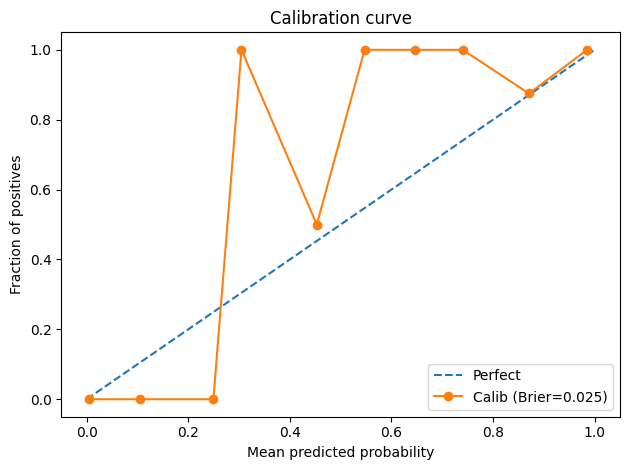

In [5]:

# Probabilities from best model
proba = best_est.predict_proba(XA_te)[:,1]

# Choose threshold by maximizing F1 on test (for demo; in production, tune on validation)
from sklearn.metrics import f1_score, recall_score, precision_score
best_thr, best_f1 = 0.5, -1
for thr in np.linspace(0.1, 0.9, 41):
    y_hat = (proba >= thr).astype(int)
    f1 = f1_score(yA_te, y_hat)
    if f1 > best_f1: best_f1, best_thr = f1, thr

y_pred_default = (proba >= 0.5).astype(int)
y_pred_tuned   = (proba >= best_thr).astype(int)

print(f"Best threshold by F1: {best_thr:.2f} (F1={best_f1:.3f})")
print("Default(0.5):  precision=", round(precision_score(yA_te, y_pred_default),3),
      " recall=", round(recall_score(yA_te, y_pred_default),3),
      " f1=", round(f1_score(yA_te, y_pred_default),3))
print("Tuned:",       " precision=", round(precision_score(yA_te, y_pred_tuned),3),
      " recall=", round(recall_score(yA_te, y_pred_tuned),3),
      " f1=", round(f1_score(yA_te, y_pred_tuned),3))

# Calibration curve
frac_pos, mean_pred = calibration_curve(yA_te, proba, n_bins=10, strategy="uniform")
br = brier_score_loss(yA_te, proba)
plt.figure()
plt.plot([0,1],[0,1],'--', label="Perfect")
plt.plot(mean_pred, frac_pos, marker="o", label=f"Calib (Brier={br:.3f})")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction of positives"); plt.title("Calibration curve")
plt.legend(); plt.tight_layout(); plt.savefig(FIGS/f"A_calibration_{best_name}.png", bbox_inches="tight"); 
# plt.close()
print("Saved:", FIGS/f"A_calibration_{best_name}.png")



### 2.3 Diagnostics: ROC, PR, Confusion Matrices, Learning Curve
These plots expose separability, class-imbalance behavior, and data efficiency.


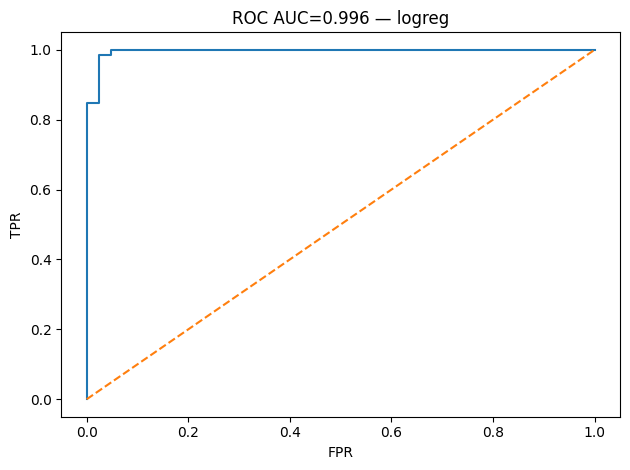

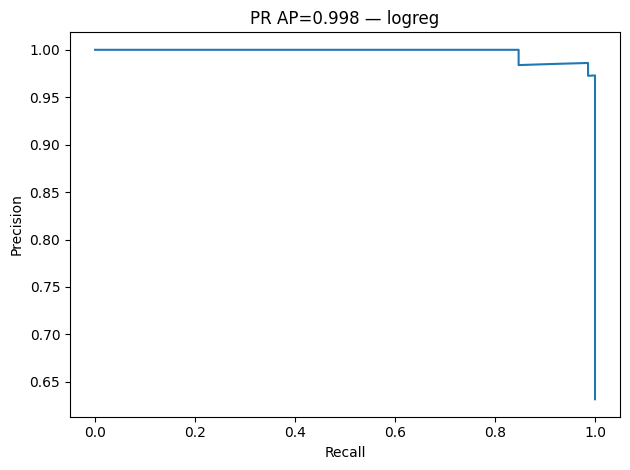

<Figure size 640x480 with 0 Axes>

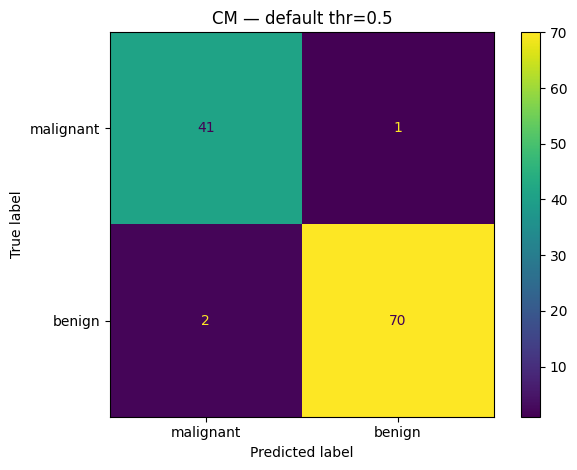

<Figure size 640x480 with 0 Axes>

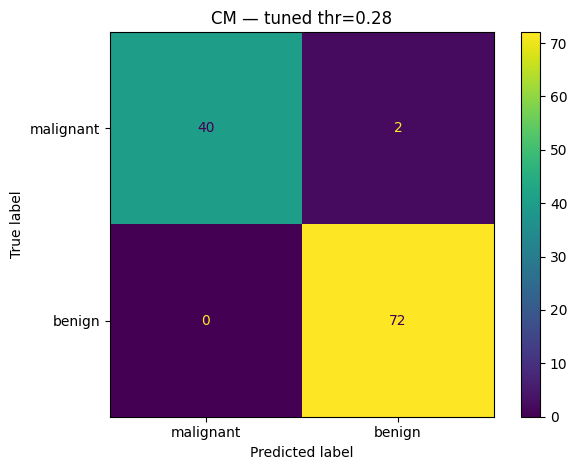

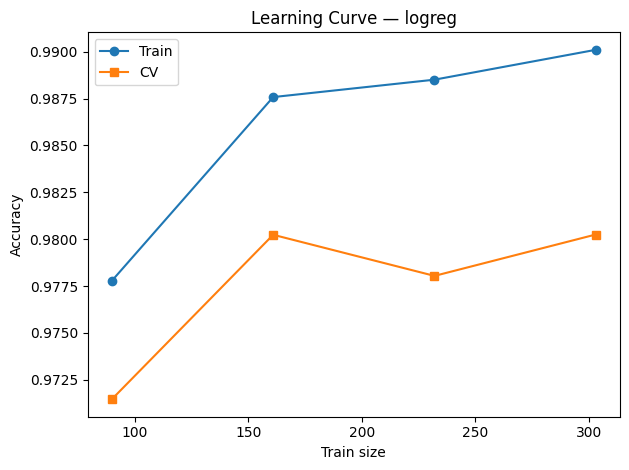

In [6]:

# ROC / PR
fpr,tpr,_ = roc_curve(yA_te, proba); auc = roc_auc_score(yA_te, proba)
prec,rec,_ = precision_recall_curve(yA_te, proba); ap = average_precision_score(yA_te, proba)

plt.figure(); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],'--'); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC AUC={auc:.3f} — {best_name}")
plt.tight_layout(); plt.savefig(FIGS/f"A_roc_{best_name}.png", bbox_inches="tight"); 
# plt.close()

plt.figure(); plt.plot(rec,prec); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"PR AP={ap:.3f} — {best_name}")
plt.tight_layout(); plt.savefig(FIGS/f"A_pr_{best_name}.png", bbox_inches="tight"); 
# plt.close()

# Confusion matrices: default vs tuned threshold
cm_def = confusion_matrix(yA_te, y_pred_default)
cm_tun = confusion_matrix(yA_te, y_pred_tuned)

plt.figure(); ConfusionMatrixDisplay(cm_def, display_labels=data.target_names).plot(values_format="d"); plt.title("CM — default thr=0.5")
plt.tight_layout(); plt.savefig(FIGS/f"A_cm_default_{best_name}.png", bbox_inches="tight"); 
# plt.close()

plt.figure(); ConfusionMatrixDisplay(cm_tun, display_labels=data.target_names).plot(values_format="d"); plt.title(f"CM — tuned thr={best_thr:.2f}")
plt.tight_layout(); plt.savefig(FIGS/f"A_cm_tuned_{best_name}.png", bbox_inches="tight"); 
# plt.close()

# Learning curve
ts, tr_sc, va_sc = learning_curve(best_est, XA_tr, yA_tr, cv=3, n_jobs=1, train_sizes=np.linspace(0.3,1.0,4), scoring="accuracy")
plt.figure(); plt.plot(ts, tr_sc.mean(axis=1), marker="o", label="Train"); plt.plot(ts, va_sc.mean(axis=1), marker="s", label="CV")
plt.xlabel("Train size"); plt.ylabel("Accuracy"); plt.title(f"Learning Curve — {best_name}"); plt.legend(); plt.tight_layout()
plt.savefig(FIGS/f"A_learning_curve_{best_name}.png", bbox_inches="tight"); 
# plt.close()



### 2.4 Capacity Sweep (Over/Under/Right Fit)
We vary RF `max_depth` and plot train vs test accuracy.  
- **Overfit**: train ≫ test.  
- **Underfit**: both low.  
- **Right fit**: near the test-accuracy peak with small generalization gap.


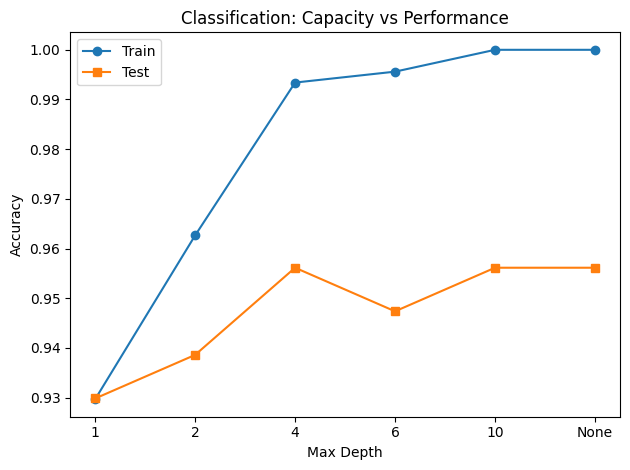

In [7]:

depths = [1, 2, 4, 6, 10, None]
train_acc, test_acc = [], []
for d in depths:
    clf = Pipeline([("sc", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=200, max_depth=d, random_state=RNG))])
    clf.fit(XA_tr, yA_tr)
    train_acc.append(clf.score(XA_tr, yA_tr))
    test_acc.append(clf.score(XA_te, yA_te))

plt.figure(); xs=[str(d) for d in depths]
plt.plot(xs, train_acc, marker="o", label="Train")
plt.plot(xs, test_acc, marker="s", label="Test")
plt.xlabel("Max Depth"); plt.ylabel("Accuracy"); plt.title("Classification: Capacity vs Performance")
plt.legend(); plt.tight_layout(); plt.savefig(FIGS/"A_overfit_curve.png", bbox_inches="tight"); 
# plt.close()



## 3. Dataset B — Regression with Missingness
**Objective:** Predict a continuous target under **missing data**.  
We inject both **MCAR** (random) and simple **MAR** (missingness correlates with a feature) to illustrate pitfalls.  
Models: **Ridge** (linear) vs **Random Forest** (nonlinear). Pipelines include **imputation**.


In [8]:

# Generate data
Xb, yb = make_regression(n_samples=1200, n_features=12, n_informative=8, noise=15.0, random_state=RNG)
Xb = pd.DataFrame(Xb, columns=[f"f{i}" for i in range(Xb.shape[1])])

# Missingness: MCAR on f0..f3 (~12%)
rng = np.random.default_rng(RNG)
mcar = rng.uniform(size=Xb[["f0","f1","f2","f3"]].shape) < 0.12
Xb.loc[mcar.reshape(-1,4).any(axis=1), ["f0","f1","f2","f3"]] = np.nan

# MAR: if f4 is high, increase missing rate on f5
mask_mar = Xb["f4"] > Xb["f4"].quantile(0.7)
mar_rand = rng.uniform(size=mask_mar.sum()) < 0.3
Xb.loc[mask_mar[mask_mar].index[mar_rand], "f5"] = np.nan

print("Missing counts (top):")
display(Xb.isnull().sum().sort_values(ascending=False).head())

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.2, random_state=RNG)

# Pipelines with imputation
ridge = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler(with_mean=False)), ("reg", Ridge(alpha=1.0, random_state=RNG))])
rf    = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler(with_mean=False)), ("reg", RandomForestRegressor(n_estimators=400, random_state=RNG))])

models = {"ridge": ridge, "rf": rf}
reg_results = {}
best_r, best_est, best_mse = None, None, np.inf

for name, mdl in models.items():
    mdl.fit(Xb_tr, yb_tr)
    tr = mdl.predict(Xb_tr); te = mdl.predict(Xb_te)
    mse_tr = mean_squared_error(yb_tr, tr); mse_te = mean_squared_error(yb_te, te)
    r2_tr  = r2_score(yb_tr, tr);         r2_te  = r2_score(yb_te, te)
    reg_results[name] = {"mse_train": float(mse_tr), "mse_test": float(mse_te), "r2_train": float(r2_tr), "r2_test": float(r2_te)}
    path = MODELS/f"B_{name}_reg.joblib"; joblib.dump(mdl, path); reg_results[name]["saved_to"] = str(path)
    if mse_te < best_mse: best_mse, best_r, best_est = mse_te, name, mdl

resB = pd.DataFrame(reg_results).T.sort_values("mse_test")
display(resB); resB.to_csv(REPTS/"B_regression_results.csv")
print("Saved:", REPTS/"B_regression_results.csv")
print("Selected best (lower MSE):", best_r)


Missing counts (top):


f0    487
f1    487
f2    487
f3    487
f5    115
dtype: int64

,mse_train,mse_test,r2_train,r2_test,saved_to
ridge,3962.166201,3955.022881,0.836259,0.818462,models/B_ridge_reg.joblib
rf,1004.902214,7337.84913,0.958471,0.663189,models/B_rf_reg.joblib


Saved: reports/B_regression_results.csv
Selected best (lower MSE): ridge



### 3.1 Residual Diagnostics (Ridge vs RF)
We check:  
- **Residuals vs Predicted** (should be centered, no trend)  
- **Histogram of residuals** (approx symmetric)  
- **Standardized residuals** to spot outliers (|z|>3).


Saved residual panels for ridge and rf


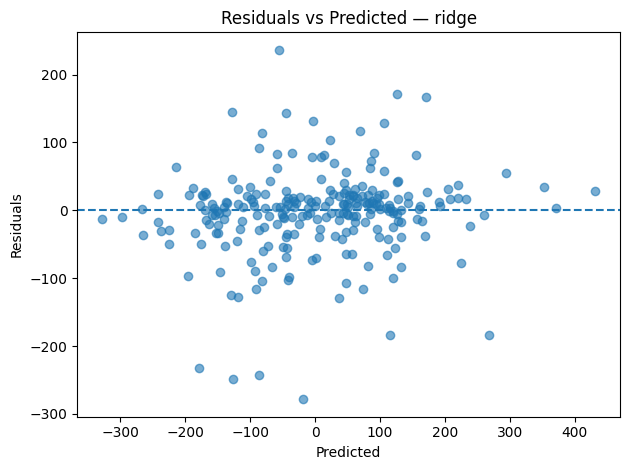

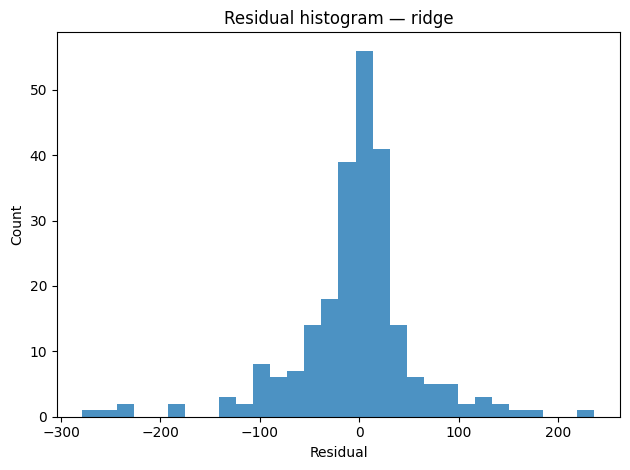

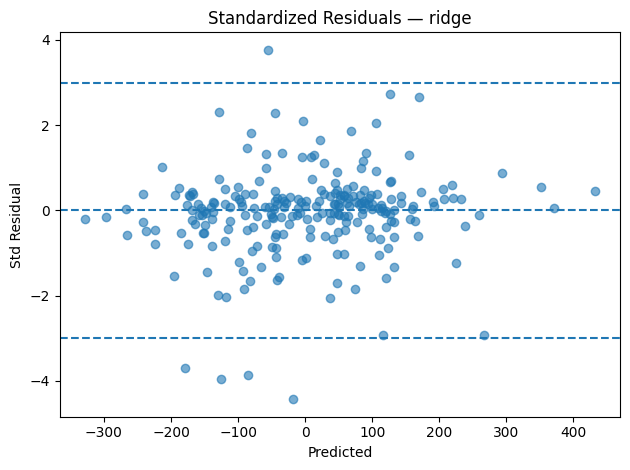

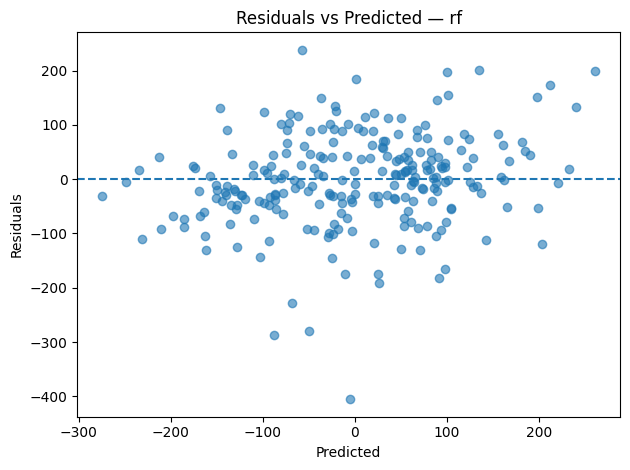

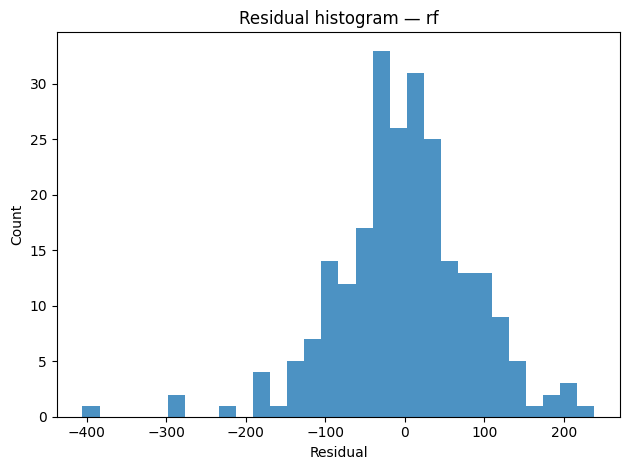

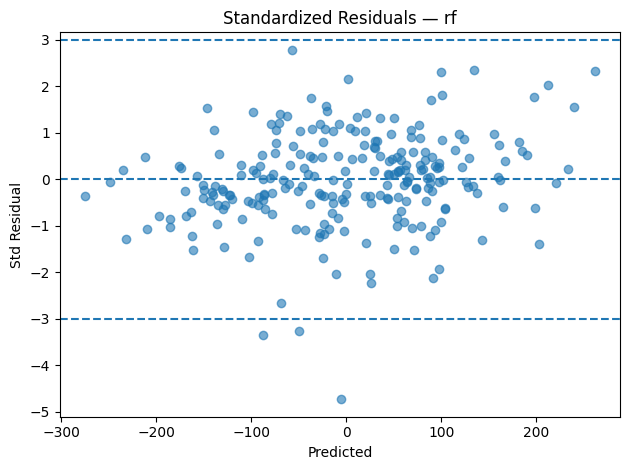

In [9]:

def residual_panel(model, Xte, yte, tag):
    pred = model.predict(Xte); resid = yte - pred
    # Scatter
    plt.figure(); plt.scatter(pred, resid, alpha=0.6); plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted"); plt.ylabel("Residuals"); plt.title(f"Residuals vs Predicted — {tag}")
    plt.tight_layout(); plt.savefig(FIGS/f"B_resid_scatter_{tag}.png", bbox_inches="tight"); 
    # plt.close()
    # Histogram
    plt.figure(); plt.hist(resid, bins=30, alpha=0.8); plt.xlabel("Residual"); plt.ylabel("Count"); plt.title(f"Residual histogram — {tag}")
    plt.tight_layout(); plt.savefig(FIGS/f"B_resid_hist_{tag}.png", bbox_inches="tight"); 
    # plt.close()
    # Standardized residuals
    std = np.std(resid) if np.std(resid)>0 else 1.0
    z = resid/std
    plt.figure(); plt.scatter(pred, z, alpha=0.6); plt.axhline(0, linestyle="--"); plt.axhline(3, linestyle="--"); plt.axhline(-3, linestyle="--")
    plt.xlabel("Predicted"); plt.ylabel("Std Residual"); plt.title(f"Standardized Residuals — {tag}")
    plt.tight_layout(); plt.savefig(FIGS/f"B_resid_std_{tag}.png", bbox_inches="tight"); 
    # plt.close()

# Panels for both models
for name, mdl in models.items():
    residual_panel(mdl, Xb_te, yb_te, tag=name)
print("Saved residual panels for ridge and rf")



### 3.2 Capacity Sweep (Regression)
Vary RF `max_depth` and track train/test MSE.  
Expect **U-shaped** test curve. The **right fit** lies near the minimum test MSE.


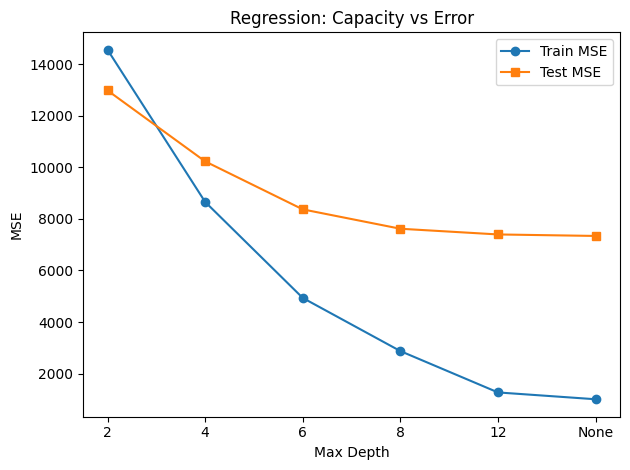

In [10]:

depths = [2, 4, 6, 8, 12, None]
tr, te = [], []
for d in depths:
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler(with_mean=False)),
                     ("reg", RandomForestRegressor(n_estimators=400, max_depth=d, random_state=RNG))])
    pipe.fit(Xb_tr, yb_tr)
    tr.append(mean_squared_error(yb_tr, pipe.predict(Xb_tr)))
    te.append(mean_squared_error(yb_te, pipe.predict(Xb_te)))

plt.figure(); xs=[str(d) for d in depths]
plt.plot(xs, tr, marker="o", label="Train MSE")
plt.plot(xs, te, marker="s", label="Test MSE")
plt.xlabel("Max Depth"); plt.ylabel("MSE"); plt.title("Regression: Capacity vs Error"); plt.legend(); plt.tight_layout()
plt.savefig(FIGS/"B_overfit_curve.png", bbox_inches="tight"); 
# plt.close()



## 4. PyTorch NN — Train/Val Curves & Early Stopping
We train a small MLP on Dataset A (classification).  
- Use **BCEWithLogitsLoss** and track **train/val** loss & accuracy.  
- Select the **best epoch** by minimum validation loss; save weights + scaler.


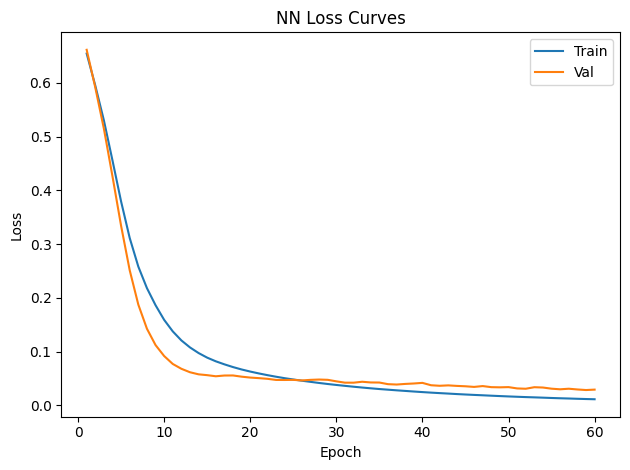

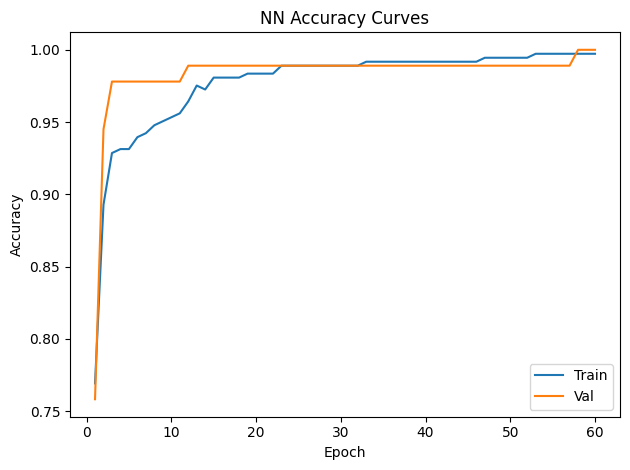

In [14]:

from math import inf

# Standardize (train-only)
sc_nn = StandardScaler().fit(XA_tr)
Xtr_t = torch.tensor(sc_nn.transform(XA_tr), dtype=torch.float32)
ytr_t = torch.tensor(yA_tr.to_numpy().reshape(-1,1), dtype=torch.float32)

# Internal train/val split
ds = TensorDataset(Xtr_t, ytr_t)
n_val = max(1, int(0.2*len(ds))); n_tr = len(ds)-n_val
tr_ds, va_ds = random_split(ds, [n_tr, n_val], generator=torch.Generator().manual_seed(RNG))
tr_dl = DataLoader(tr_ds, batch_size=64, shuffle=True)
va_dl = DataLoader(va_ds, batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
    def forward(self,x): return self.net(x)

m = MLP(Xtr_t.shape[1]); crit=nn.BCEWithLogitsLoss(); opt=optim.Adam(m.parameters(), lr=1e-3)
E=60; trL=[]; vaL=[]; trA=[]; vaA=[]; best=(inf,None)
for e in range(1,E+1):
    m.train()
    for xb,yb in tr_dl:
        opt.zero_grad(); loss=crit(m(xb), yb); loss.backward(); opt.step()
    # evaluate
    m.eval()
    with torch.no_grad():
        def eval_dl(dl):
            L=N=C=0
            for xb,yb in dl:
                lg=m(xb); L += crit(lg,yb).item()*len(xb); N += len(xb)
                pr=(torch.sigmoid(lg)>=0.5).int(); C += (pr==yb.int()).sum().item()
            return L/N, C/N
        tl, ta = eval_dl(tr_dl); vl, va = eval_dl(va_dl)
    trL.append(tl); vaL.append(vl); trA.append(ta); vaA.append(va)
    if vl < best[0]: best=(vl, {k:v.clone() for k,v in m.state_dict().items()})

# restore best epoch
m.load_state_dict(best[1])
torch.save({"state_dict": m.state_dict(), "scaler_mean": sc_nn.mean_, "scaler_scale": sc_nn.scale_}, MODELS/"A_nn_bundle.pt")

# Curves
plt.figure(); plt.plot(range(1,E+1), trL, label="Train"); plt.plot(range(1,E+1), vaL, label="Val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("NN Loss Curves"); plt.legend(); plt.tight_layout()
plt.savefig(FIGS/"A_nn_loss.png", bbox_inches="tight"); 
# plt.close()

plt.figure(); plt.plot(range(1,E+1), trA, label="Train"); plt.plot(range(1,E+1), vaA, label="Val")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("NN Accuracy Curves"); plt.legend(); plt.tight_layout()
plt.savefig(FIGS/"A_nn_acc.png", bbox_inches="tight"); 
# plt.close()



## 5. Model Cards (Concise) & Reproducibility
**Classification (best)**: document data, preprocessing, estimator, hyperparams, metrics, decision threshold, calibration, and known limitations.  
**Regression (best)**: document missingness mechanism, imputation strategy, error distribution, and stability across seeds.

We also save a **summary index** to `reports/summary.json` giving paths to artifacts.


In [12]:

summary = {
    "paths": {"models": str(MODELS), "figures": str(FIGS), "reports": str(REPTS)},
    "classification": {
        "best_model": str(MODELS/f"A_{best_name}_pipeline.joblib"),
        "figures": {
            "pca": str(FIGS/"A_pca_train.png"),
            "roc": str(FIGS/f"A_roc_{best_name}.png"),
            "pr": str(FIGS/f"A_pr_{best_name}.png"),
            "cm_default": str(FIGS/f"A_cm_default_{best_name}.png"),
            "cm_tuned": str(FIGS/f"A_cm_tuned_{best_name}.png"),
            "calibration": str(FIGS/f"A_calibration_{best_name}.png"),
            "learning_curve": str(FIGS/f"A_learning_curve_{best_name}.png"),
            "capacity": str(FIGS/"A_overfit_curve.png"),
            "nn_loss": str(FIGS/"A_nn_loss.png"),
            "nn_acc": str(FIGS/"A_nn_acc.png"),
        }
    },
    "regression": {
        "results_csv": str(REPTS/"B_regression_results.csv"),
        "figures": {
            "ridge_scatter": str(FIGS/"B_resid_scatter_ridge.png"),
            "ridge_hist": str(FIGS/"B_resid_hist_ridge.png"),
            "ridge_std": str(FIGS/"B_resid_std_ridge.png"),
            "rf_scatter": str(FIGS/"B_resid_scatter_rf.png"),
            "rf_hist": str(FIGS/"B_resid_hist_rf.png"),
            "rf_std": str(FIGS/"B_resid_std_rf.png"),
            "capacity": str(FIGS/"B_overfit_curve.png"),
        }
    }
}
with open(REPTS/"summary.json","w") as f: json.dump(summary, f, indent=2)
print("Saved:", REPTS/"summary.json")


Saved: reports/summary.json
